# Customer Lifetime & Retention Analysis — UK Gift E-commerce

**A loyal core is masking a leaky acquisition funnel.**

This notebook analyses ~12 months of transactions from a UK-based online gift retailer
(UCI *Online Retail* dataset) to answer one question: *is revenue growth healthy, or is it
hiding a customer-retention problem?*

The pipeline is pure **pandas** (cleaning → RFM segmentation → cohort retention →
new-vs-returning revenue), running end-to-end on the full dataset in `data/`.
**Every chart in the README is produced by this notebook** and saved to `images/charts/`.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA_PATH = "../data/ecommerce_retail.csv"   # full dataset — works after git clone
CHART_DIR = "../images/charts"               # README charts are written here
os.makedirs(CHART_DIR, exist_ok=True)
ANALYSIS_DATE = pd.Timestamp("2011-12-31")   # snapshot for Recency

# Shared chart theme (keeps every figure visually consistent)
INK, ACCENT, WARN, MUTE, GRID = "#1b2a41", "#2a9d8f", "#e76f51", "#d8dbe0", "#eef0f2"
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 150, "font.size": 12,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK, "ytick.color": INK, "axes.linewidth": 0.8,
    "figure.facecolor": "white", "axes.facecolor": "white", "font.family": "DejaVu Sans",
})
def _style(ax):
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.grid(axis="y", color=GRID, lw=1, zorder=0)
    ax.set_axisbelow(True)

## 1. Load & clean

Three cleaning rules, each with a business reason:
1. **Drop cancellations** (`InvoiceNo` starting with `C`) — returns, not demand.
2. **Keep only real product lines** (5-digit `StockCode`) — removes postage, fees, `AMAZONFEE`, bank charges.
3. **Flag guests** (null `CustomerID`) — they can't be tracked across visits, so RFM excludes them.

In [2]:
def load_clean(path):
    cols = ["InvoiceNo","StockCode","Description","Quantity",
            "InvoiceDate","UnitPrice","CustomerID","Country"]
    df = pd.read_csv(path, usecols=cols,
                     dtype={"InvoiceNo":str,"StockCode":str},
                     parse_dates=["InvoiceDate"])
    df = df[~df["InvoiceNo"].str.startswith("C")]                 # rule 1
    df = df[df["StockCode"].str.match(r"^\d{5}.*$")].copy()       # rule 2
    df["CustomerType"] = np.where(df["CustomerID"].isna(), "Guest", "Registered")  # rule 3
    df["Revenue"] = df["Quantity"] * df["UnitPrice"]             # list price × qty (no discount field)
    return df

df = load_clean(DATA_PATH)
print(f"Clean rows: {len(df):,}")
print(df["CustomerType"].value_counts())
df.head(3)

Clean rows: 530,210
CustomerType
Registered    396370
Guest         133840
Name: count, dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerType,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,Registered,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,Registered,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,Registered,22.00


### Guests vs registered
Guests are ~25% of rows but can't be tracked over time. Everything downstream (RFM, cohorts)
uses **registered customers only**; guest revenue is reported separately.

In [3]:
rev_split = df.groupby("CustomerType")["Revenue"].sum()
print((rev_split / rev_split.sum() * 100).round(1).astype(str) + " %")
reg = df[df["CustomerType"] == "Registered"].copy()

CustomerType
Guest         14.7 %
Registered    85.3 %
Name: Revenue, dtype: str


### Chart — monthly revenue (context)
Total monthly revenue (all customers). Sets the scene: revenue builds into the Q4 gifting season.

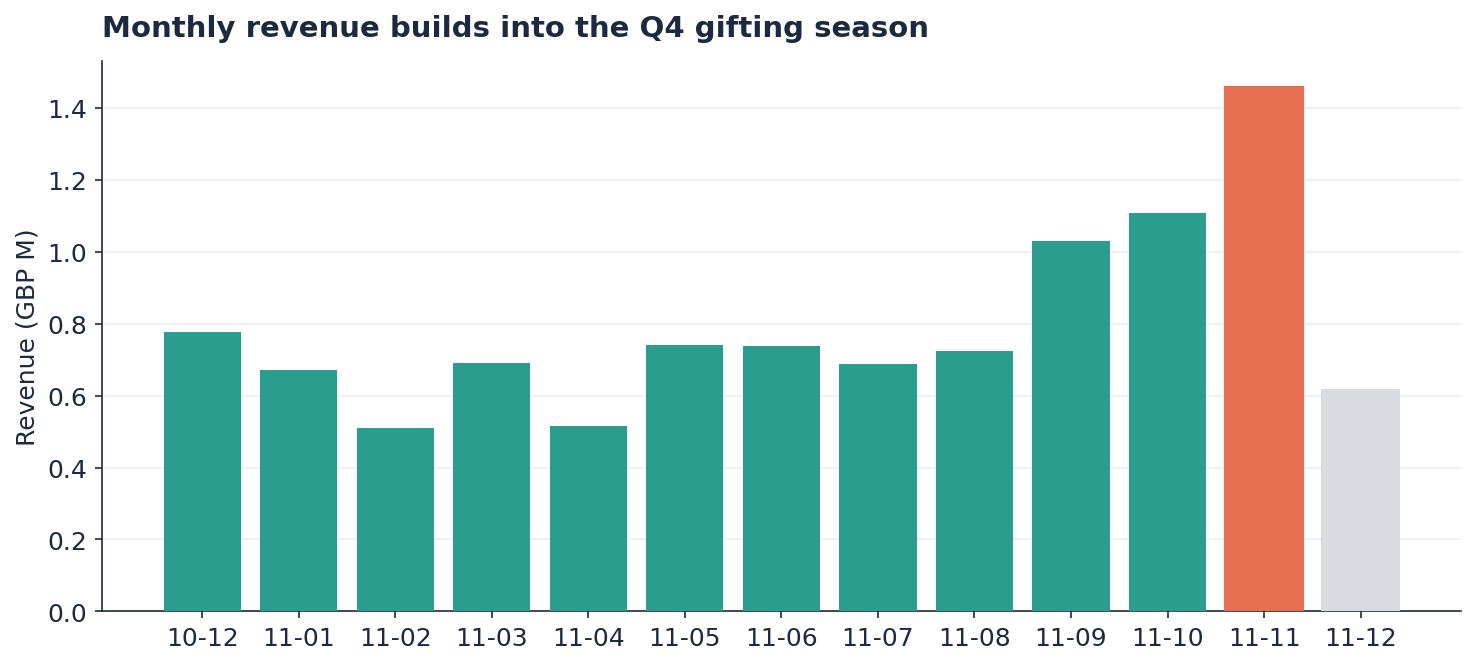

In [4]:
m = df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"].sum() / 1e6
fig, ax = plt.subplots(figsize=(10, 4.6))
xs = np.arange(len(m))
bars = ax.bar(xs, m.values, color=ACCENT, zorder=3)
bars[list(m.index).index(pd.Period("2011-11"))].set_color(WARN)  # Nov peak
bars[-1].set_color(MUTE)                                          # partial Dec
_style(ax)
ax.set_xticks(xs); ax.set_xticklabels([str(p)[2:] for p in m.index])
ax.set_ylabel("Revenue (GBP M)")
ax.set_title("Monthly revenue builds into the Q4 gifting season",
             fontsize=14, fontweight="bold", loc="left", pad=12)
fig.tight_layout(); fig.savefig(f"{CHART_DIR}/monthly_revenue_trend.png", bbox_inches="tight")
plt.show()

## 2. RFM table
For each registered customer: **Recency** (days since last order), **Frequency** (distinct invoices),
**Monetary** (total revenue). Then quintile scores 1–5.

In [5]:
rfm = (reg.groupby("CustomerID")
          .agg(LastPurchase=("InvoiceDate","max"),
               Frequency=("InvoiceNo","nunique"),
               Monetary=("Revenue","sum"))
          .reset_index())
rfm["Recency"] = (ANALYSIS_DATE - rfm["LastPurchase"]).dt.days
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=False, duplicates="drop")
rfm["R_Score"] = rfm["R_Score"].max() - rfm["R_Score"] + 1   # invert: recent = high
rfm["F_Score"] = pd.qcut(rfm["Frequency"], 5, labels=False, duplicates="drop") + 1  # matches dashboard rfm_segment.py
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=False, duplicates="drop") + 1
rfm["RFM"] = rfm[["R_Score","F_Score","M_Score"]].astype(str).agg("".join, axis=1)
rfm.head()

,CustomerID,LastPurchase,Frequency,Monetary,Recency,R_Score,F_Score,M_Score,RFM
0,"12,346.00",2011-01-18 10:01:00,1,"77,183.60",346,1,1,5,115
1,"12,347.00",2011-12-07 15:52:00,7,"4,310.00",23,5,4,5,545
2,"12,348.00",2011-09-25 13:13:00,4,"1,437.24",96,2,3,4,234
3,"12,349.00",2011-11-21 09:51:00,1,"1,457.55",39,4,1,4,414
4,"12,350.00",2011-02-02 16:01:00,1,294.40,331,1,1,2,112


### Map RFM codes to named segments (standard 11-segment grid)

In [6]:
SEGMENT_MAP = {
    "Champions": {"555","554","544","545","454","455","445"},
    "Loyal": {"543","444","435","355","354","345","344","335"},
    "Potential Loyalist": {"553","551","552","541","542","533","532","531","452","451","442","441","431","453","433","432","423","353","352","351","342","341","333","323"},
    "New Customers": {"512","511","422","421","412","411","311"},
    "Promising": {"525","524","523","522","521","515","514","513","425","424","413","414","415","315","314","313"},
    "Need Attention": {"535","534","443","434","343","334","325","324"},
    "About To Sleep": {"331","321","312","221","213","231","241","251"},
    "At Risk": {"255","254","245","244","253","252","243","242","235","234","225","224","153","152","145","143","142","135","134","133","125","124"},
    "Cannot Lose Them": {"155","154","144","214","215","115","114","113"},
    "Hibernating": {"332","322","233","232","223","222","132","123","122","212","211"},
    "Lost": {"111","112","121","131","141","151"},
}
def to_segment(code):
    for seg, codes in SEGMENT_MAP.items():
        if code in codes:
            return seg
    return "Others"

rfm["Segment"] = rfm["RFM"].map(to_segment)
seg = (rfm.groupby("Segment")
          .agg(Customers=("CustomerID","count"), Revenue=("Monetary","sum")))
seg["Cust_%"] = (seg["Customers"]/seg["Customers"].sum()*100).round(1)
seg["Rev_%"]  = (seg["Revenue"]/seg["Revenue"].sum()*100).round(1)
seg.sort_values("Rev_%", ascending=False)

,Customers,Revenue,Cust_%,Rev_%
Segment,,,,
Champions,610,"5,048,739.02",14.10,57.60
Loyal,250,"796,955.88",5.80,9.10
Promising,492,"702,009.84",11.30,8.00
At Risk,238,"559,501.48",5.50,6.40
Need Attention,345,"553,998.44",8.00,6.30
Cannot Lose Them,229,"352,846.78",5.30,4.00
About To Sleep,331,"163,439.46",7.60,1.90
Hibernating,484,"164,598.59",11.20,1.90
Potential Loyalist,228,"157,580.67",5.30,1.80


### Chart — customer share vs revenue share by segment
The imbalance made concrete: Champions are a small share of customers but most of the revenue.

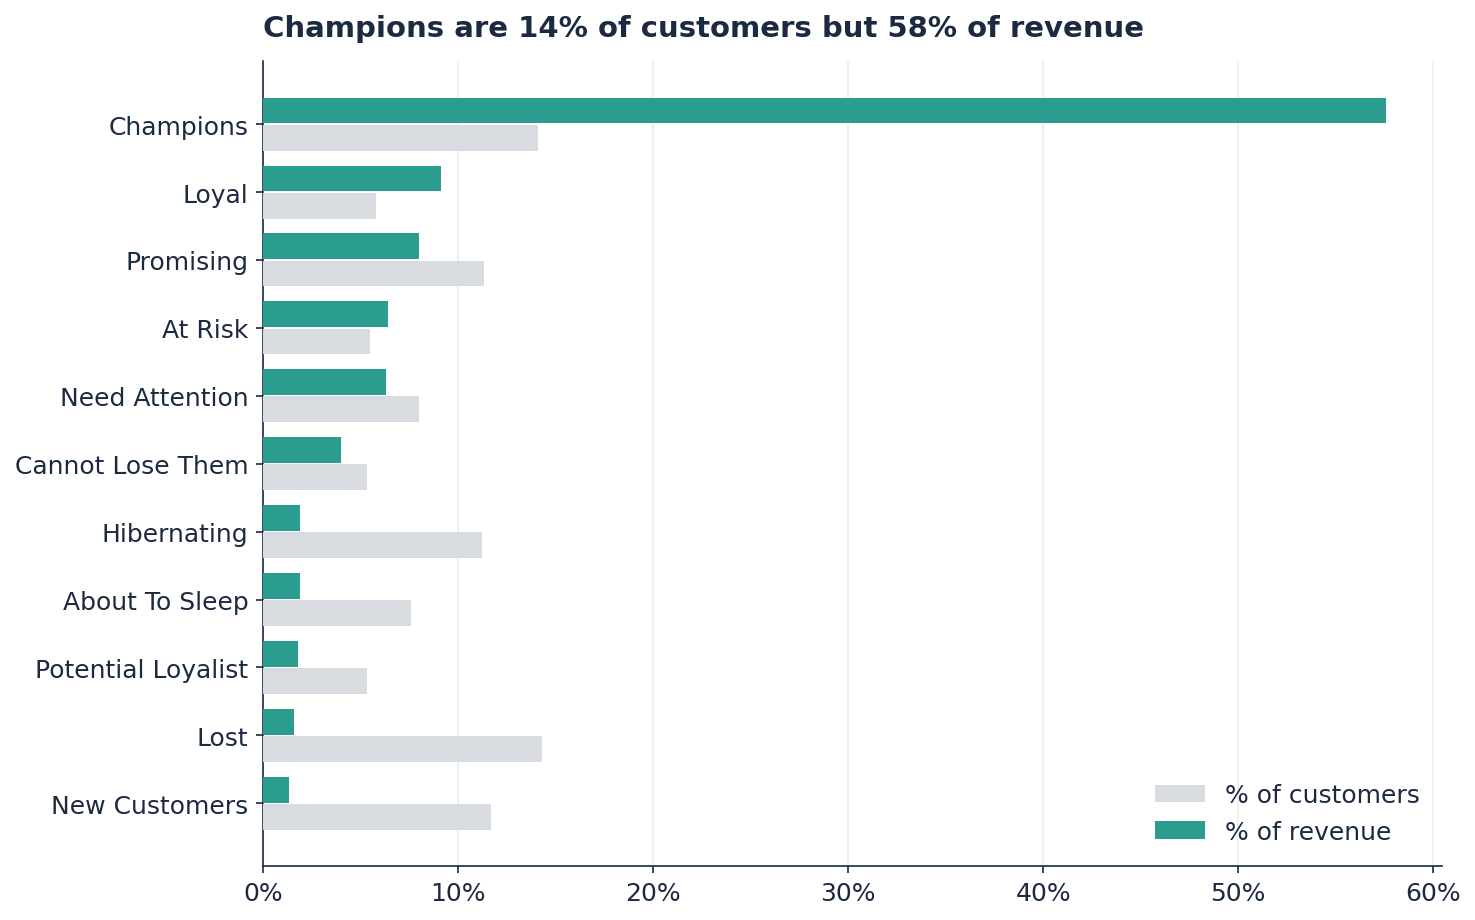

In [7]:
g = seg.sort_values("Rev_%")
y = np.arange(len(g))
fig, ax = plt.subplots(figsize=(10, 6.3))
ax.barh(y-0.2, g["Cust_%"], height=0.38, color=MUTE, label="% of customers", zorder=3)
ax.barh(y+0.2, g["Rev_%"], height=0.38, color=ACCENT, label="% of revenue", zorder=3)
for s in ["top","right"]:
    ax.spines[s].set_visible(False)
ax.grid(axis="x", color=GRID, lw=1); ax.set_axisbelow(True)
ax.set_yticks(y); ax.set_yticklabels(g.index)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
champ = seg.loc["Champions"]
ax.set_title(f"Champions are {champ['Cust_%']:.0f}% of customers but {champ['Rev_%']:.0f}% of revenue",
             fontsize=14, fontweight="bold", loc="left", pad=12)
ax.legend(loc="lower right", frameon=False)
fig.tight_layout(); fig.savefig(f"{CHART_DIR}/segment_customers_vs_revenue.png", bbox_inches="tight")
plt.show()

### Chart — revenue concentration (Pareto)

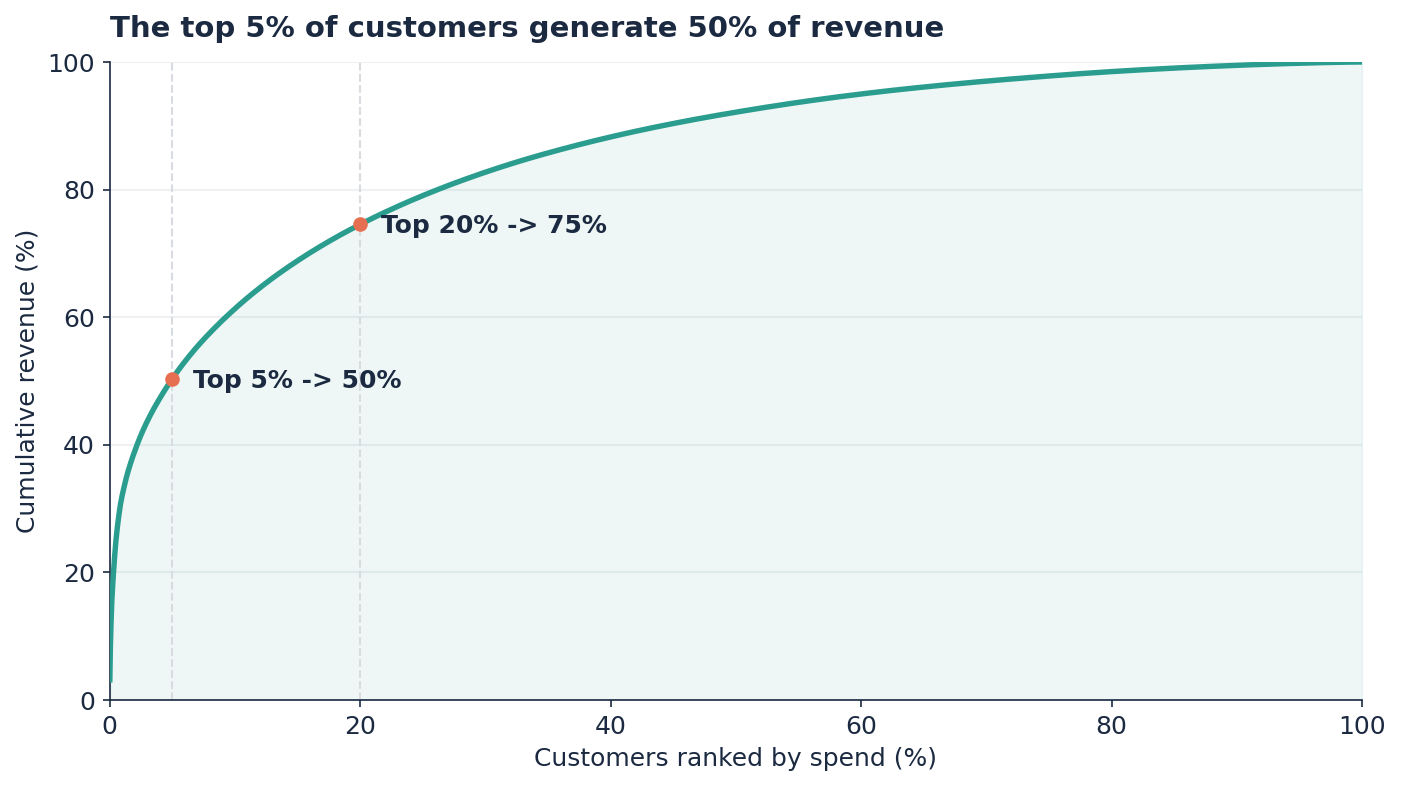

In [8]:
cust_rev = rfm.sort_values("Monetary", ascending=False)["Monetary"].values
cum = np.cumsum(cust_rev) / cust_rev.sum() * 100
pctl = np.arange(1, len(cum)+1) / len(cum) * 100
top5 = cum[max(0,int(len(cum)*0.05))-1]; top20 = cum[max(0,int(len(cum)*0.20))-1]
fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.plot(pctl, cum, color=ACCENT, lw=2.6, zorder=3)
ax.fill_between(pctl, cum, color=ACCENT, alpha=0.08)
_style(ax)
for p, c in [(5, top5), (20, top20)]:
    ax.axvline(p, color=MUTE, ls="--", lw=1, zorder=1)
    ax.plot([p], [c], "o", color=WARN, zorder=5)
    ax.annotate(f"Top {p}% -> {c:.0f}%", (p, c), textcoords="offset points",
                xytext=(10,-4), fontweight="bold", color=INK)
ax.set_xlabel("Customers ranked by spend (%)"); ax.set_ylabel("Cumulative revenue (%)")
ax.set_xlim(0,100); ax.set_ylim(0,100)
ax.set_title(f"The top 5% of customers generate {top5:.0f}% of revenue",
             fontsize=14, fontweight="bold", loc="left", pad=12)
fig.tight_layout(); fig.savefig(f"{CHART_DIR}/revenue_concentration_pareto.png", bbox_inches="tight")
plt.show()

**Concentration + one-time vs repeat.** Repeat buyers are worth far more, so retention is a revenue question.

In [9]:
one_time = (rfm["Frequency"] == 1).mean() * 100
ratio = rfm.loc[rfm["Frequency"]>=2,"Monetary"].mean() / rfm.loc[rfm["Frequency"]==1,"Monetary"].mean()
for p in [5, 10, 20]:
    n = max(1, int(len(cust_rev)*p/100))
    print(f"Top {p:>2}% of customers -> {cum[n-1]:.1f}% of revenue")
print(f"One-time buyers: {one_time:.1f}% of customers")
print(f"Repeat buyers spend {ratio:.1f}x more on average than one-time buyers")

Top  5% of customers -> 50.3% of revenue
Top 10% of customers -> 61.3% of revenue
Top 20% of customers -> 74.5% of revenue
One-time buyers: 34.7% of customers
Repeat buyers spend 6.9x more on average than one-time buyers


## 3. Cohort retention — where do customers drop off?
Group customers by first-purchase month, then track how many return each following month.

In [10]:
reg["OrderMonth"]  = reg["InvoiceDate"].dt.to_period("M")
reg["CohortMonth"] = reg.groupby("CustomerID")["OrderMonth"].transform("min")
reg["CohortIndex"] = ((reg["OrderMonth"].dt.year  - reg["CohortMonth"].dt.year)*12
                    +  (reg["OrderMonth"].dt.month - reg["CohortMonth"].dt.month) + 1)
counts = (reg.groupby(["CohortMonth","CohortIndex"])["CustomerID"].nunique()
             .reset_index()
             .pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID"))
retention = counts.divide(counts[1], axis=0)
(retention * 100).round(0)

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,100.00,37.00,32.00,38.00,36.00,40.00,36.00,35.00,35.00,39.00,37.00,50.00,26.00
2011-01,100.00,22.00,27.00,23.00,32.00,29.00,25.00,24.00,30.00,33.00,37.00,12.00,NaN
2011-02,100.00,19.00,19.00,29.00,27.00,24.00,26.00,27.00,25.00,31.00,7.00,NaN,NaN
2011-03,100.00,15.00,25.00,20.00,22.00,17.00,27.00,23.00,28.00,9.00,NaN,NaN,NaN
2011-04,100.00,21.00,20.00,21.00,20.00,23.00,22.00,26.00,7.00,NaN,NaN,NaN,NaN
2011-05,100.00,19.00,17.00,17.00,21.00,23.00,26.00,10.00,NaN,NaN,NaN,NaN,NaN
2011-06,100.00,17.00,16.00,26.00,23.00,33.00,10.00,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.00,18.00,20.00,22.00,27.00,11.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.00,20.00,24.00,24.00,12.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Chart — cohort retention heatmap

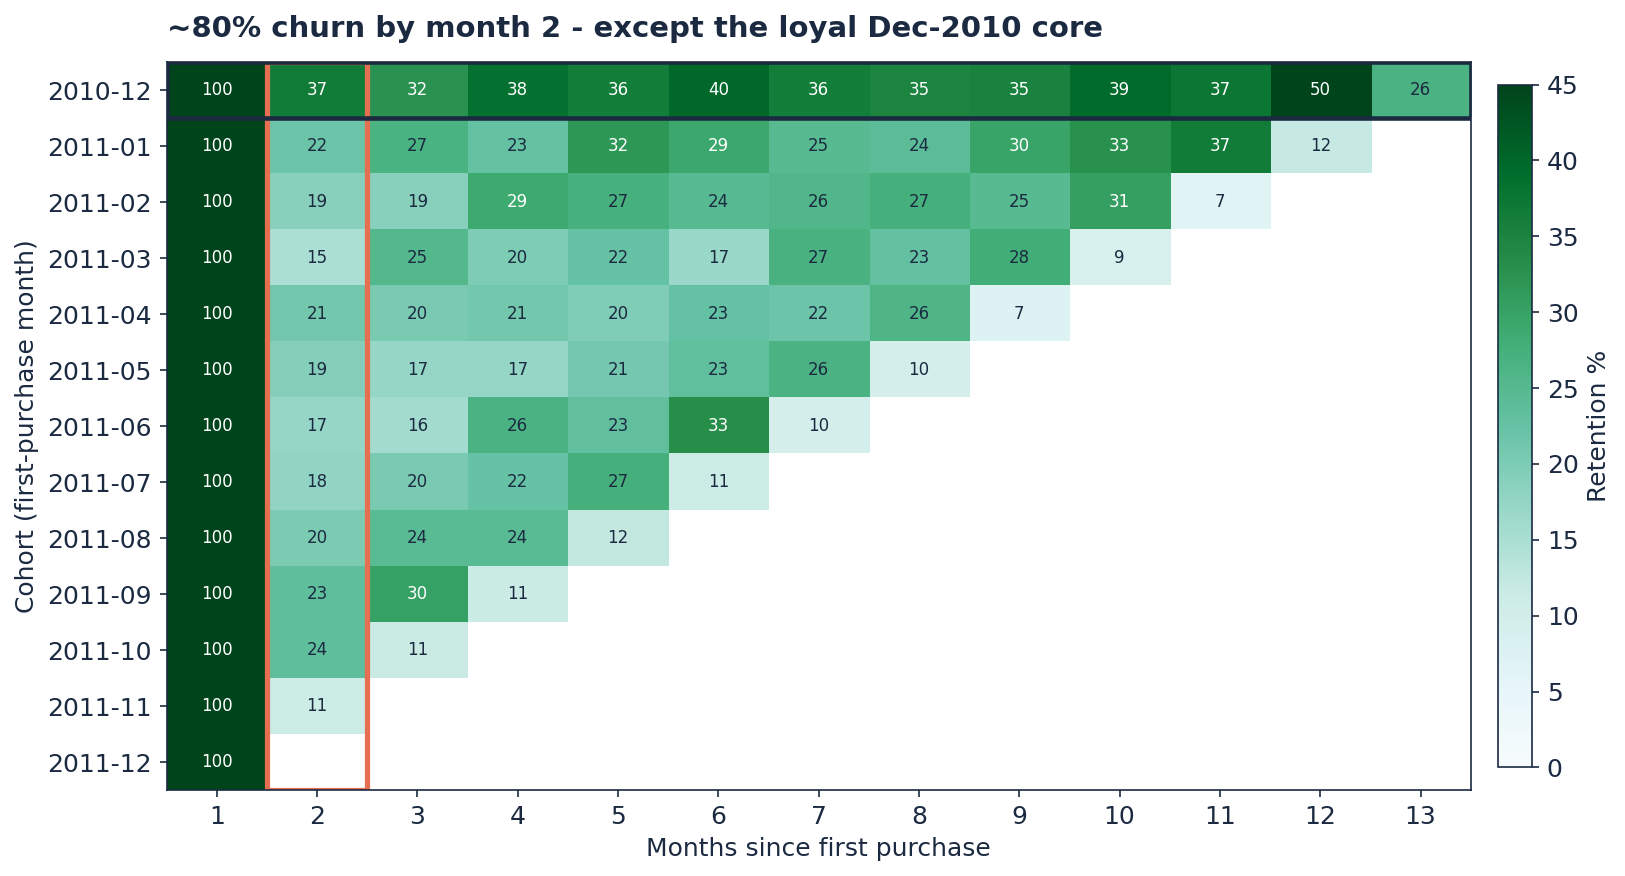

In [11]:
M = retention.values * 100
fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(M, aspect="auto", cmap="BuGn", vmin=0, vmax=45)
ax.set_xticks(range(M.shape[1])); ax.set_xticklabels(range(1, M.shape[1]+1))
ax.set_yticks(range(M.shape[0])); ax.set_yticklabels([str(p) for p in retention.index])
ax.set_xlabel("Months since first purchase"); ax.set_ylabel("Cohort (first-purchase month)")
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                    color="white" if v > 28 else INK, fontsize=8)
ax.add_patch(plt.Rectangle((0.5,-.5), 1, M.shape[0], fill=False, ec=WARN, lw=2.5))   # month-2 cliff
ax.add_patch(plt.Rectangle((-.5,-.5), M.shape[1], 1, fill=False, ec=INK, lw=2.2))    # Dec-2010 core
ax.set_title("~80% churn by month 2 - except the loyal Dec-2010 core",
             fontsize=14, fontweight="bold", loc="left", pad=12)
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02); cb.set_label("Retention %")
fig.tight_layout(); fig.savefig(f"{CHART_DIR}/cohort_retention_heatmap.png", bbox_inches="tight")
plt.show()

In [12]:
m2 = retention[2].dropna()
print(f"Average month-2 retention: {m2.mean()*100:.1f}%  ->  churn {100-m2.mean()*100:.1f}%")

Average month-2 retention: 20.4%  ->  churn 79.6%


## 4. New vs returning revenue — the punchline
Split each month's revenue into first-time and returning customers.

In [13]:
reg["is_new"] = reg["OrderMonth"] == reg["CohortMonth"]
mr = (reg.groupby(["OrderMonth","is_new"])["Revenue"].sum().unstack().fillna(0))
mr.columns = ["Returning","New"]
mr["Returning_share_%"] = (mr["Returning"]/(mr["Returning"]+mr["New"])*100).round(1)
mr

,Returning,New,Returning_share_%
OrderMonth,,,
2010-12,0.00,"567,490.72",0.00
2011-01,"274,152.84","289,873.80",48.60
2011-02,"285,654.49","157,691.53",64.40
2011-03,"387,345.73","197,217.12",66.30
2011-04,"335,108.32","120,158.59",73.60
2011-05,"541,539.52","118,942.38",82.00
2011-06,"520,516.38","133,916.18",79.50
2011-07,"520,183.77","72,548.13",87.80
2011-08,"558,185.26","78,621.98",87.70


### Chart — new vs returning revenue (the thesis in one figure)

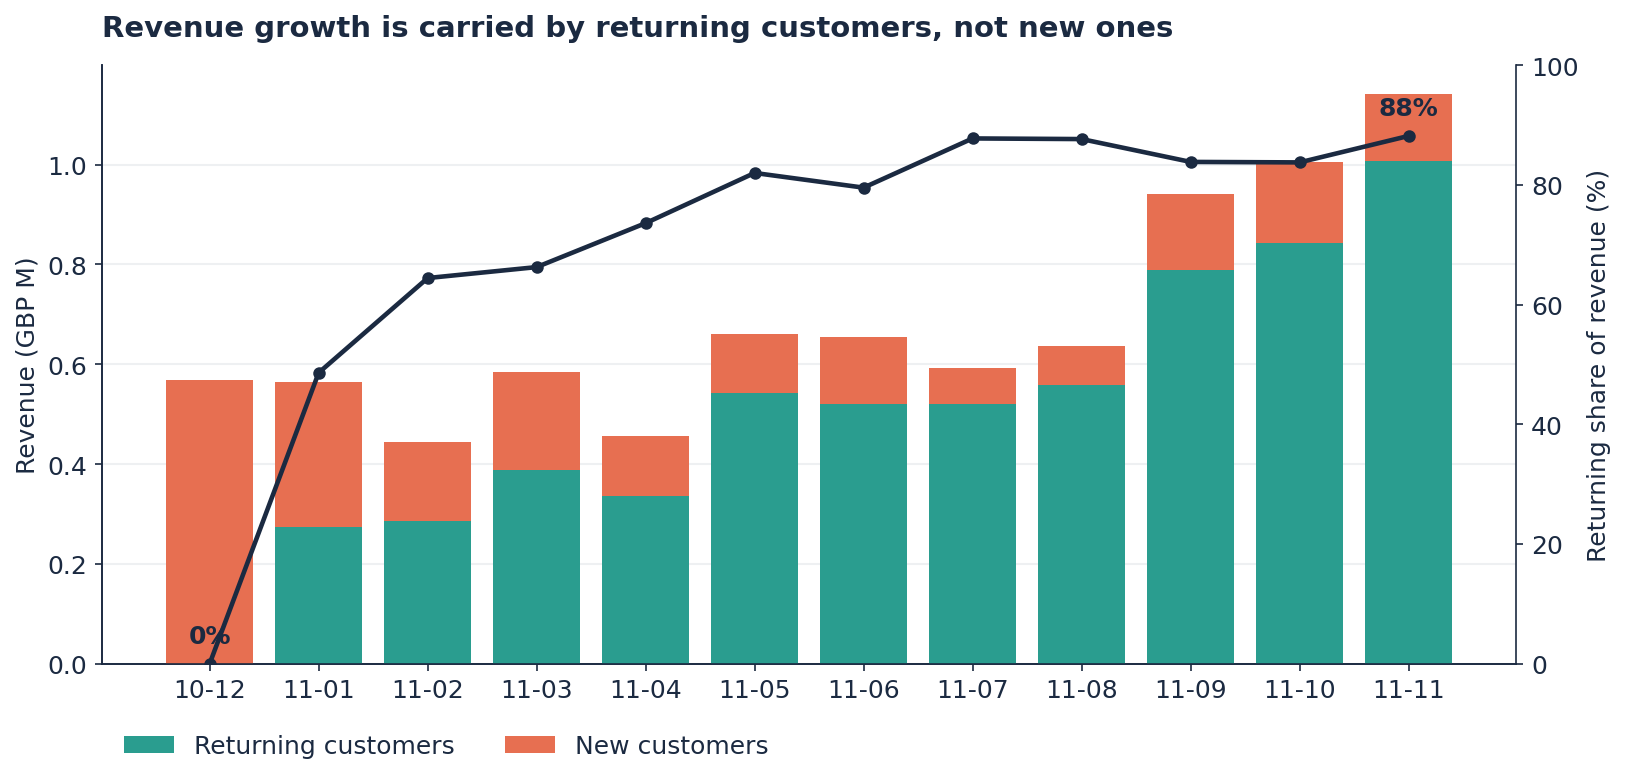

In [14]:
mrp = mr[mr.index < pd.Period("2011-12")]          # drop partial final month
x = np.arange(len(mrp))
ret = mrp["Returning"].values/1e6; new = mrp["New"].values/1e6
share = (mrp["Returning"]/(mrp["Returning"]+mrp["New"])*100).values
fig, ax = plt.subplots(figsize=(11, 5.4))
ax.bar(x, ret, color=ACCENT, label="Returning customers", zorder=3)
ax.bar(x, new, bottom=ret, color=WARN, label="New customers", zorder=3)
_style(ax)
ax.set_xticks(x); ax.set_xticklabels([str(p)[2:] for p in mrp.index])
ax.set_ylabel("Revenue (GBP M)")
ax2 = ax.twinx(); ax2.plot(x, share, color=INK, lw=2.2, marker="o", ms=5, zorder=5)
ax2.set_ylim(0,100); ax2.set_ylabel("Returning share of revenue (%)"); ax2.spines["top"].set_visible(False)
for i in [0, len(x)-1]:
    ax2.annotate(f"{share[i]:.0f}%", (x[i], share[i]), textcoords="offset points",
                 xytext=(0,10), ha="center", fontweight="bold", color=INK)
ax.set_title("Revenue growth is carried by returning customers, not new ones",
             fontsize=14, fontweight="bold", loc="left", pad=14)
ax.legend(loc="upper left", frameon=False, ncol=2, bbox_to_anchor=(0,-0.08))
fig.tight_layout(); fig.savefig(f"{CHART_DIR}/new_vs_returning_revenue.png", bbox_inches="tight")
plt.show()

Returning-customer revenue share climbs from ~49% to ~88% across the year — growth rests on the
existing base, which is why the leaky acquisition funnel is a slow-burning risk.

---
### Key takeaways
1. **Champions (~14% of customers) drive ~58% of revenue** — revenue is concentrated in a loyal core.
2. **~80% of every new cohort churns by month 2** — the acquisition funnel leaks badly.
3. **Returning-customer revenue share rises 49% → 88%** — growth rests on the core, with a thin new-customer pipeline.